In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob

def plot_ccgs_from_index_tsv(
    index_tsv_path: str,
    spike_times_by_probe: dict,
    hemisphere_dict: dict | None = None,
    out_dir: str | None = None,              # if provided, saves figures; else just shows/returns
    which: int | list[int] | slice | None = None,
    # CCG params (should match what you used when creating the TSV, but you can override)
    bin_s: float | None = None,
    half_window_s: float | None = None,
    start_s: float | None = None,
    end_s: float | None = None,
    # plotting
    figsize=(7.0, 3.8),
    show: bool = True,
    save: bool = False,
    dpi: int = 200,
    overwrite: bool = False,
):
    """
    Load a TSV (like theta_skip_index.tsv) containing ref/tgt probe+cluster ids and plot CCGs
    for exactly those pairs. Optionally select a subset via `which`.

    Expected TSV columns (minimum):
      ref_probe, ref_cluster, tgt_probe, tgt_cluster
    Optional columns used if present:
      hemi_pair, path, bin_s, half_window_s, start_s, end_s, expected_period_s, etc.

    Parameters
    ----------
    which
        - None: plot all pairs in TSV
        - int: plot only that row index (0-based)
        - list[int]: plot those indices
        - slice: plot that slice of rows (e.g., slice(0, 20))
    out_dir
        If provided and save=True, figures will be written here. If TSV already contains
        a 'path' column, we will default to that location unless out_dir is set.

    Returns
    -------
    figs : list[matplotlib.figure.Figure]
        List of figures created (also saved if save=True).
    rows : list[dict]
        Parsed rows used for plotting.
    """
    def _read_tsv(path):
        rows = []
        with open(path, "r", encoding="utf-8") as f:
            header = f.readline().rstrip("\n").split("\t")
            for line in f:
                if not line.strip():
                    continue
                parts = line.rstrip("\n").split("\t")
                row = {k: (parts[i] if i < len(parts) else "") for i, k in enumerate(header)}
                rows.append(row)
        return rows

    def _to_int(x, default=None):
        try:
            return int(float(x))
        except Exception:
            return default

    def _to_float(x, default=None):
        try:
            return float(x)
        except Exception:
            return default

    def compute_ccg_counts(spk_ref, spk_tgt, bin_s=0.001, half_window_s=0.25, t0=None, t1=None):
        spk_ref = np.asarray(spk_ref, dtype=float)
        spk_tgt = np.asarray(spk_tgt, dtype=float)

        if t0 is not None:
            spk_ref = spk_ref[spk_ref >= t0]
            spk_tgt = spk_tgt[spk_tgt >= t0]
        if t1 is not None:
            spk_ref = spk_ref[spk_ref <= t1]
            spk_tgt = spk_tgt[spk_tgt <= t1]

        edges = np.arange(-half_window_s, half_window_s + bin_s, bin_s)
        centers = 0.5 * (edges[:-1] + edges[1:])
        counts = np.zeros(len(centers), dtype=int)

        if spk_ref.size == 0 or spk_tgt.size == 0:
            return centers, counts

        spk_tgt = np.sort(spk_tgt)
        for tr in spk_ref:
            left = np.searchsorted(spk_tgt, tr - half_window_s, side="left")
            right = np.searchsorted(spk_tgt, tr + half_window_s, side="right")
            if right <= left:
                continue
            d = spk_tgt[left:right] - tr
            counts += np.histogram(d, bins=edges)[0]
        return centers, counts

    # ---- load rows ----
    all_rows = _read_tsv(index_tsv_path)

    # remove potential blank rows where required columns missing
    rows = []
    for r in all_rows:
        if _to_int(r.get("ref_probe", ""), None) is None:   # header-only or empty file
            continue
        if _to_int(r.get("ref_cluster", ""), None) is None:
            continue
        if _to_int(r.get("tgt_probe", ""), None) is None:
            continue
        if _to_int(r.get("tgt_cluster", ""), None) is None:
            continue
        rows.append(r)

    if len(rows) == 0:
        raise ValueError("No usable rows found in TSV. Need columns: ref_probe, ref_cluster, tgt_probe, tgt_cluster.")

    # ---- select subset ----
    if which is None:
        sel = list(range(len(rows)))
    elif isinstance(which, int):
        sel = [which]
    elif isinstance(which, slice):
        sel = list(range(len(rows)))[which]
    else:
        sel = list(which)

    # bounds check
    sel = [i for i in sel if 0 <= i < len(rows)]
    if len(sel) == 0:
        raise ValueError("Selection `which` produced no valid indices.")

    # ---- make output dir if needed ----
    if out_dir is not None and save:
        os.makedirs(out_dir, exist_ok=True)

    figs = []
    used_rows = []

    for idx in sel:
        r = rows[idx]
        ref_probe = _to_int(r["ref_probe"])
        ref_cluster = _to_int(r["ref_cluster"])
        tgt_probe = _to_int(r["tgt_probe"])
        tgt_cluster = _to_int(r["tgt_cluster"])

        # Resolve per-row defaults if available
        row_bin = _to_float(r.get("bin_s", ""), None)
        row_hw  = _to_float(r.get("half_window_s", ""), None)
        row_t0  = _to_float(r.get("start_s", ""), None)
        row_t1  = _to_float(r.get("end_s", ""), None)

        bs = bin_s if bin_s is not None else (row_bin if row_bin is not None else 0.001)
        hw = half_window_s if half_window_s is not None else (row_hw if row_hw is not None else 0.25)
        t0 = start_s if start_s is not None else row_t0
        t1 = end_s if end_s is not None else row_t1

        # Pull spike times
        try:
            spk_ref = spike_times_by_probe[ref_probe][ref_cluster]
        except KeyError:
            raise KeyError(f"Missing ref unit in spike_times_by_probe: probe {ref_probe}, cluster {ref_cluster}")
        try:
            spk_tgt = spike_times_by_probe[tgt_probe][tgt_cluster]
        except KeyError:
            raise KeyError(f"Missing tgt unit in spike_times_by_probe: probe {tgt_probe}, cluster {tgt_cluster}")

        tau, counts = compute_ccg_counts(spk_ref, spk_tgt, bin_s=bs, half_window_s=hw, t0=t0, t1=t1)

        ref_hemi = hemisphere_dict.get(ref_probe, "?") if hemisphere_dict is not None else "?"
        tgt_hemi = hemisphere_dict.get(tgt_probe, "?") if hemisphere_dict is not None else "?"

        ref_name = f"p{ref_probe:02d}_c{ref_cluster:04d}"
        tgt_name = f"p{tgt_probe:02d}_c{tgt_cluster:04d}"

        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
        ax.bar(tau, counts, width=bs, align="center")
        ax.axvline(0.0, linewidth=1.0)
        ax.set_xlabel(r"$\tau = t_{\mathrm{tgt}} - t_{\mathrm{ref}}$ (s)")
        ax.set_ylabel("Count")
        ax.set_title(f"CCG [{idx}]  {ref_name} ({ref_hemi}) → {tgt_name} ({tgt_hemi})")

        ann = [f"bin={bs*1000:.2f} ms  halfwin={hw*1000:.0f} ms"]
        if t0 is not None or t1 is not None:
            ann.append(f"window: [{t0 if t0 is not None else '-inf'}, {t1 if t1 is not None else 'inf'}] s")
        # include any useful scoring columns if present
        for k in ("trough_z", "peakp_z", "peakn_z", "peak_over_trough"):
            if k in r and r[k] != "":
                ann.append(f"{k}={r[k]}")
        ax.text(0.99, 0.98, "\n".join(ann), ha="right", va="top", transform=ax.transAxes, fontsize=9)

        # ---- save logic ----
        if save:
            # Prefer explicit 'path' in TSV unless overridden by out_dir
            default_path = r.get("path", "")
            if out_dir is not None or not default_path:
                # put in out_dir with a clean name
                od = out_dir if out_dir is not None else os.path.dirname(index_tsv_path)
                os.makedirs(od, exist_ok=True)
                fname = f"{ref_name}__{tgt_name}__ccg_idx{idx}.png"
                fpath = os.path.join(od, fname)
            else:
                # replace filename but keep directory, to avoid clobbering "thetaSkip" figures
                d = os.path.dirname(default_path)
                os.makedirs(d, exist_ok=True)
                fname = f"{ref_name}__{tgt_name}__ccg_idx{idx}.png"
                fpath = os.path.join(d, fname)

            if (not overwrite) and os.path.exists(fpath):
                plt.close(fig)
            else:
                fig.savefig(fpath, dpi=dpi)
        if show:
            plt.show()
        else:
            plt.close(fig)

        figs.append(fig)
        used_rows.append(r)

    return figs, used_rows

def load_spike_times(ks_dir, use_units='good'):
    """Load spike times from Kilosort output directory."""
    # Load cluster info
    cluster_info_path = os.path.join(ks_dir, 'cluster_group.tsv')
    cluster_info = np.genfromtxt(cluster_info_path, delimiter='\t', names=True, dtype=None, encoding='utf-8')
    
    # Determine which clusters to use
    if use_units == 'good':
        valid_clusters = cluster_info['cluster_id'][cluster_info['KSLabel'] == 'good']
    elif use_units == 'mua':
        valid_clusters = cluster_info['cluster_id'][(cluster_info['KSLabel'] == 'mua') | (cluster_info['KSLabel'] == 'good')]
    else:
        valid_clusters = cluster_info['cluster_id']
    
    # Load spike times
    spike_times_path = os.path.join(ks_dir, 'spike_times_sec_adj.npy')
    all_spike_times = np.load(spike_times_path)  # in seconds
    
    # Load spike clusters
    spike_clusters_path = os.path.join(ks_dir, 'spike_clusters.npy')
    all_spike_clusters = np.load(spike_clusters_path)
    
    # Filter spikes for valid clusters
    spike_times = {}
    for cluster_id in valid_clusters:
        spike_times[cluster_id] = all_spike_times[all_spike_clusters == cluster_id]
    
    return spike_times

In [2]:
# ----------------------------- Config ---------------------------------

# Data paths and session info
DATA_DIR = r"Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251107"
FIG_DIR = os.path.join(DATA_DIR, "figures")
ANALYSIS_DIR = os.path.join(DATA_DIR, "gplvm_results")
SESSION_NAME = os.path.basename(DATA_DIR)
BASE_NAME = SESSION_NAME
PROBES = [0, 1, 2, 3]  # List of probe numbers to include


# Spike rate computation parameters
WINDOW_SIZE = 0.01         # s
STEP_SIZE   = 0.01       # s
USE_UNITS   = "good"       # {'all', 'good', 'mua'}


# Filtering thresholds
MIN_TOTAL_SPIKES   = 500
MIN_MEAN_RATE_HZ   = 0.01
MIN_PRESENCE_RATIO = 0.50
N_TIME_BINS        = 100    # coarse bins for presence ratio


# defining the region dictionary. Keys are probe numbers, values are dictionaries which are further mapping shanks to regions
region_dict = {
    0: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1'},
    1: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1'},
    2: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'Th', 5: 'Th'}, 
    3: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1'}
} #This is going to need to be replaced by manual unit labels....


# defining the hemisphere dictionary. Keys are probe numbers, values are 'L' or 'R' for left/right hemisphere
hemisphere_dict = {0: 'L', 1: 'L', 2: 'R', 3: 'R'}

# Create figure directory if it doesn't exist
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
spike_times = {}
for probe in PROBES:

        
    # Get the raw spike counts and the zscored and smoothed spike rates
    pattern = os.path.join(DATA_DIR, f"Kilosort*imec{probe}*")
    matches = glob.glob(pattern)
    ks_dir = matches[0]  # assuming there's only one match
    print(f"Loading spike times from Kilosort directory: {ks_dir}")

    spike_times[probe] = load_spike_times(ks_dir, use_units=USE_UNITS)
    print(spike_times[probe].keys())
    

Loading spike times from Kilosort directory: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251107\Kilosort_imec0_ks4
dict_keys([2, 7, 11, 14, 16, 21, 24, 25, 30, 31, 33, 34, 35, 36, 44, 46, 47, 48, 50, 52, 54, 57, 58, 59, 60, 62, 63, 64, 66, 67, 71, 72, 73, 77, 80, 82, 86, 87, 89, 90, 92, 93, 98, 99, 101, 103, 104, 106, 107, 110, 111, 113, 114, 116, 155, 165, 168, 172, 174, 176, 186, 187, 189, 192, 198, 201, 208, 209, 215, 220, 221, 223, 225, 226, 228, 229, 233, 236, 237, 241, 247, 248, 249, 253, 254, 257, 262, 266, 267, 269, 272, 273, 274, 276, 281, 282, 283, 284, 288, 292, 294, 298, 300, 303, 304, 316, 324, 339, 344, 356, 361, 362, 363, 373, 379, 382])
Loading spike times from Kilosort directory: Z:\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251107\Kilosort_imec1_ks4
dict_keys([0, 8, 17, 82, 86, 88, 89, 92, 105, 106, 118, 120, 123, 125, 126, 131, 134, 141, 146, 151, 156, 158, 159, 162, 163, 172, 174, 176, 182, 183, 189, 191, 197, 200, 204, 206, 208, 211, 212, 213, 219, 222, 2

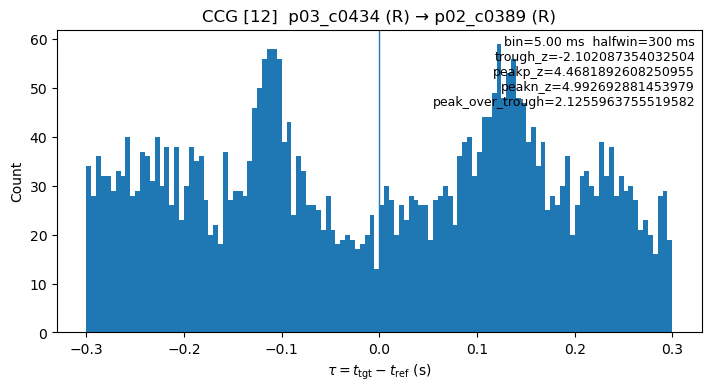

([<Figure size 700x380 with 1 Axes>],
 [{'hemi_pair': 'R',
   'ref_probe': '3',
   'ref_cluster': '434',
   'tgt_probe': '2',
   'tgt_cluster': '389',
   'bin_s': '0.005',
   'half_window_s': '0.3',
   'expected_period_s': '0.125',
   'require_both_sides': 'True',
   'trough_z': '-2.102087354032504',
   'peakp_z': '4.4681892608250955',
   'peakn_z': '4.992692881453979',
   'peak_over_trough': '2.1255963755519582',
   'start_s': 'None',
   'end_s': 'None',
   'path': 'Z:\\Homes\\voerom01\\Bilat_HPC\\Bilat_R02\\Bilat_R02_20251107\\figures\\ccg_theta_cycle_skipping\\R\\p03_c0434\\p03_c0434__p02_c0389__thetaSkip_T125ms_bin5.0ms_win300ms.png'}])

In [20]:



tsv = os.path.join(FIG_DIR, "ccg_theta_cycle_skipping", "theta_skip_index.tsv")
# Plot just one (row 0):
plot_ccgs_from_index_tsv(tsv, spike_times, hemisphere_dict, which=12, show=True, save=False)


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_acgs_from_index_tsv(
    index_tsv_path: str,
    spike_times_by_probe: dict,
    hemisphere_dict: dict | None = None,
    out_dir: str | None = None,
    which: int | list[int] | slice | None = None,
    # ACG params
    bin_s: float | None = None,
    half_window_s: float | None = None,
    start_s: float | None = None,
    end_s: float | None = None,
    # plotting
    figsize=(8.0, 6.0),
    show: bool = True,
    save: bool = False,
    dpi: int = 200,
    overwrite: bool = False,
    exclude_zero_lag: bool = True,
    title_prefix: str = "ACGs",
):
    """
    Read a TSV of unit pairs (ref/tgt) and, for each selected row, plot TWO ACGs:
    one for the ref unit and one for the tgt unit.

    Expected TSV columns (minimum):
      ref_probe, ref_cluster, tgt_probe, tgt_cluster
    Optional columns used if present:
      bin_s, half_window_s, start_s, end_s, trough_z, peakp_z, etc.

    Selection via `which`:
      - None: plot all rows
      - int: single row index (0-based)
      - list[int] or slice: subset

    Returns
    -------
    figs : list[matplotlib.figure.Figure]
    used_rows : list[dict]
    """

    # ---------------- IO helpers ----------------
    def _read_tsv(path):
        rows = []
        with open(path, "r", encoding="utf-8") as f:
            header = f.readline().rstrip("\n").split("\t")
            for line in f:
                if not line.strip():
                    continue
                parts = line.rstrip("\n").split("\t")
                row = {k: (parts[i] if i < len(parts) else "") for i, k in enumerate(header)}
                rows.append(row)
        return rows

    def _to_int(x, default=None):
        try:
            return int(float(x))
        except Exception:
            return default

    def _to_float(x, default=None):
        try:
            return float(x)
        except Exception:
            return default

    # ---------------- ACG computation ----------------
    def compute_acg_counts(spk, bin_s=0.001, half_window_s=0.25, t0=None, t1=None, exclude_zero=True):
        """
        Autocorrelogram counts for tau = t_j - t_i within [-half_window, +half_window].
        Efficient-ish approach using two-pointer style accumulation over a sorted spike train.

        Returns
        -------
        centers : bin centers (s)
        counts  : histogram counts
        """
        spk = np.asarray(spk, dtype=float)

        if t0 is not None:
            spk = spk[spk >= t0]
        if t1 is not None:
            spk = spk[spk <= t1]

        spk = np.sort(spk)

        edges = np.arange(-half_window_s, half_window_s + bin_s, bin_s)
        centers = 0.5 * (edges[:-1] + edges[1:])
        counts = np.zeros(len(centers), dtype=int)

        n = spk.size
        if n < 2:
            return centers, counts

        # For each spike i, look forward to spikes j>i within +half_window_s
        # Add +dt and (symmetrically) -dt counts, avoiding explicit O(n^2) in practice.
        for i in range(n):
            ti = spk[i]
            # find the largest j such that spk[j] - ti <= half_window_s
            j_max = np.searchsorted(spk, ti + half_window_s, side="right")
            if j_max <= i + 1:
                continue
            dpos = spk[i + 1 : j_max] - ti  # strictly positive
            # histogram positive diffs, then mirror to negative
            hpos, _ = np.histogram(dpos, bins=np.arange(0.0, half_window_s + bin_s, bin_s))
            # Map hpos into counts:
            # positive bins correspond to centers in (0, half_window]
            # Build edges for positive-only and then place into full counts
            # We'll just histogram twice for simplicity (still fast enough).
            counts += np.histogram(dpos, bins=edges)[0]
            counts += np.histogram(-dpos, bins=edges)[0]

        if exclude_zero:
            # Zero-lag bin is the one containing 0
            zero_bin = np.where((centers >= -bin_s/2) & (centers < bin_s/2))[0]
            if zero_bin.size:
                counts[zero_bin[0]] = 0

        return centers, counts

    # ---------------- load & select rows ----------------
    all_rows = _read_tsv(index_tsv_path)

    rows = []
    for r in all_rows:
        if _to_int(r.get("ref_probe", ""), None) is None:   # skip malformed
            continue
        if _to_int(r.get("ref_cluster", ""), None) is None:
            continue
        if _to_int(r.get("tgt_probe", ""), None) is None:
            continue
        if _to_int(r.get("tgt_cluster", ""), None) is None:
            continue
        rows.append(r)

    if len(rows) == 0:
        raise ValueError("No usable rows found in TSV. Need columns: ref_probe, ref_cluster, tgt_probe, tgt_cluster.")

    if which is None:
        sel = list(range(len(rows)))
    elif isinstance(which, int):
        sel = [which]
    elif isinstance(which, slice):
        sel = list(range(len(rows)))[which]
    else:
        sel = list(which)

    sel = [i for i in sel if 0 <= i < len(rows)]
    if len(sel) == 0:
        raise ValueError("Selection `which` produced no valid indices.")

    if out_dir is not None and save:
        os.makedirs(out_dir, exist_ok=True)

    figs, used_rows = [], []

    # ---------------- plot loop ----------------
    for idx in sel:
        r = rows[idx]
        ref_probe = _to_int(r["ref_probe"])
        ref_cluster = _to_int(r["ref_cluster"])
        tgt_probe = _to_int(r["tgt_probe"])
        tgt_cluster = _to_int(r["tgt_cluster"])

        # per-row defaults if present
        row_bin = _to_float(r.get("bin_s", ""), None)
        row_hw  = _to_float(r.get("half_window_s", ""), None)
        row_t0  = _to_float(r.get("start_s", ""), None)
        row_t1  = _to_float(r.get("end_s", ""), None)

        bs = bin_s if bin_s is not None else (row_bin if row_bin is not None else 0.001)
        hw = half_window_s if half_window_s is not None else (row_hw if row_hw is not None else 0.25)
        t0 = start_s if start_s is not None else row_t0
        t1 = end_s if end_s is not None else row_t1

        # pull spikes
        try:
            spk_ref = spike_times_by_probe[ref_probe][ref_cluster]
        except KeyError:
            raise KeyError(f"Missing ref unit in spike_times_by_probe: probe {ref_probe}, cluster {ref_cluster}")
        try:
            spk_tgt = spike_times_by_probe[tgt_probe][tgt_cluster]
        except KeyError:
            raise KeyError(f"Missing tgt unit in spike_times_by_probe: probe {tgt_probe}, cluster {tgt_cluster}")

        # compute ACGs
        tau_r, acg_r = compute_acg_counts(spk_ref, bin_s=bs, half_window_s=hw, t0=t0, t1=t1, exclude_zero=exclude_zero_lag)
        tau_t, acg_t = compute_acg_counts(spk_tgt, bin_s=bs, half_window_s=hw, t0=t0, t1=t1, exclude_zero=exclude_zero_lag)

        # labels
        ref_hemi = hemisphere_dict.get(ref_probe, "?") if hemisphere_dict is not None else "?"
        tgt_hemi = hemisphere_dict.get(tgt_probe, "?") if hemisphere_dict is not None else "?"
        ref_name = f"p{ref_probe:02d}_c{ref_cluster:04d}"
        tgt_name = f"p{tgt_probe:02d}_c{tgt_cluster:04d}"

        # plot: two stacked axes sharing x
        fig, axes = plt.subplots(2, 1, figsize=figsize, sharex=True, constrained_layout=True)

        axes[0].bar(tau_r, acg_r, width=bs, align="center")
        axes[0].axvline(0.0, linewidth=1.0)
        axes[0].set_ylabel("Count")
        axes[0].set_title(f"{title_prefix} [{idx}]  REF {ref_name} ({ref_hemi})")

        axes[1].bar(tau_t, acg_t, width=bs, align="center")
        axes[1].axvline(0.0, linewidth=1.0)
        axes[1].set_ylabel("Count")
        axes[1].set_title(f"TGT {tgt_name} ({tgt_hemi})")
        axes[1].set_xlabel(r"$\tau$ (s)")

        # annotate (top panel)
        ann = [f"bin={bs*1000:.2f} ms  halfwin={hw*1000:.0f} ms"]
        if t0 is not None or t1 is not None:
            ann.append(f"window: [{t0 if t0 is not None else '-inf'}, {t1 if t1 is not None else 'inf'}] s")
        for k in ("trough_z", "peakp_z", "peakn_z", "peak_over_trough"):
            if k in r and r[k] != "":
                ann.append(f"{k}={r[k]}")
        axes[0].text(0.99, 0.98, "\n".join(ann), ha="right", va="top", transform=axes[0].transAxes, fontsize=9)

        # save/show
        if save:
            od = out_dir if out_dir is not None else os.path.dirname(index_tsv_path)
            os.makedirs(od, exist_ok=True)
            fpath = os.path.join(od, f"{ref_name}__{tgt_name}__acgs_idx{idx}.png")
            if overwrite or (not os.path.exists(fpath)):
                fig.savefig(fpath, dpi=dpi)

        if show:
            plt.show()
        else:
            plt.close(fig)

        figs.append(fig)
        used_rows.append(r)

    return figs, used_rows




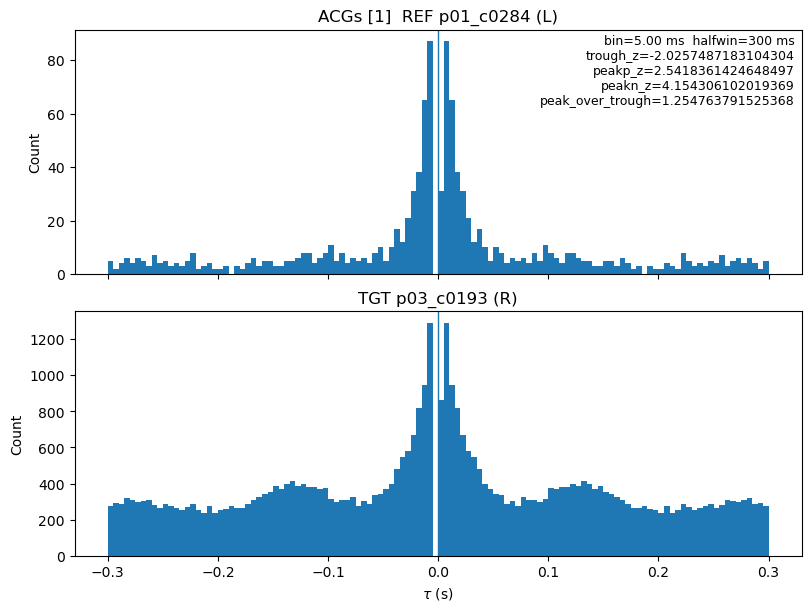

([<Figure size 800x600 with 2 Axes>],
 [{'hemi_pair': 'LR',
   'ref_probe': '1',
   'ref_cluster': '284',
   'tgt_probe': '3',
   'tgt_cluster': '193',
   'bin_s': '0.005',
   'half_window_s': '0.3',
   'expected_period_s': '0.125',
   'require_both_sides': 'True',
   'trough_z': '-2.0257487183104304',
   'peakp_z': '2.5418361424648497',
   'peakn_z': '4.154306102019369',
   'peak_over_trough': '1.254763791525368',
   'start_s': 'None',
   'end_s': 'None',
   'path': 'Z:\\Homes\\voerom01\\Bilat_HPC\\Bilat_R02\\Bilat_R02_20251107\\figures\\ccg_theta_cycle_skipping_across_hemi\\LR\\p01_c0284\\p01_c0284__p03_c0193__thetaSkip_T125ms_bin5.0ms_win300ms.png'}])

In [23]:




tsv = os.path.join(FIG_DIR, "ccg_theta_cycle_skipping_across_hemi", "theta_skip_index.tsv")
plot_acgs_from_index_tsv(tsv, spike_times, hemisphere_dict, which=1, show=True, save=False)
